In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


The dataset is synthetically generated, and some geographical inconsistencies were observed, such as mismatches between State and District values. Therefore, geographical fields were treated as dataset attributes rather than verified real-world locations.

In [5]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='str')

In [6]:
df.shape

(4000, 28)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [8]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

Median was preferred over mean for variables with skewed distributions or extreme values because the median is less affected by outliers and better represents a typical observation.

In [9]:
df['Yield_Tonnes_Ha']=df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

In [10]:
df['Soil_Moisture_pct']=df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].mean())

In [11]:
df['Rainfall_mm']=df['Rainfall_mm'].fillna(df['Rainfall_mm'].mean())

In [12]:
df.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found, so no duplicate rows were removed.

In [14]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.185807,3.81818,11.960834,1.121186,0.641461,6.678828,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,585.950000,26.90000,63.000000,7.300000,6.690000,26.500000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [15]:
df.describe(include='str')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [16]:
df.dtypes

Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [17]:
categorical_cols = df.select_dtypes(include='str').columns
numeric_cols = df.select_dtypes(include=np.number).columns

print("Categorical columns:")
print(list(categorical_cols))

print("\nNumerical columns:")
print(list(numeric_cols))

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [18]:
print("Negative values in Farm Area:",
      (df['Farm_Area_Hectares'] < 0).sum())

print("Negative values in Rainfall:",
      (df['Rainfall_mm'] < 0).sum())

print("Negative values in Profit:",
      (df['Profit_INR'] < 0).sum())

Negative values in Farm Area: 0
Negative values in Rainfall: 0
Negative values in Profit: 1966


##### Outlier Detection

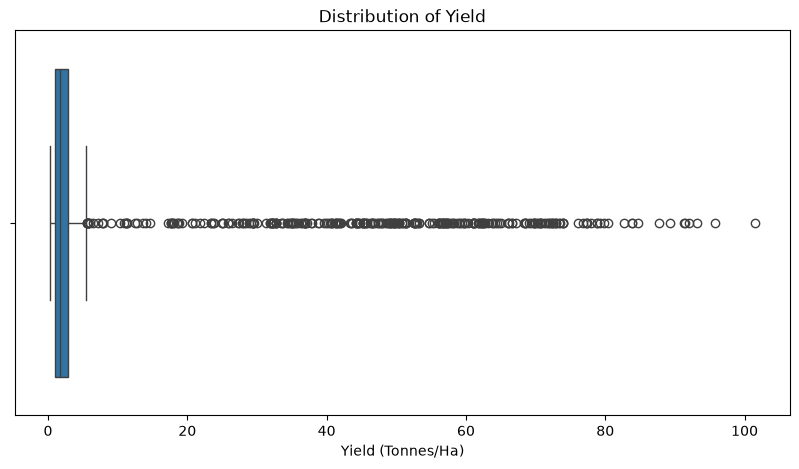

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Yield_Tonnes_Ha'])

plt.title('Distribution of Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.show()

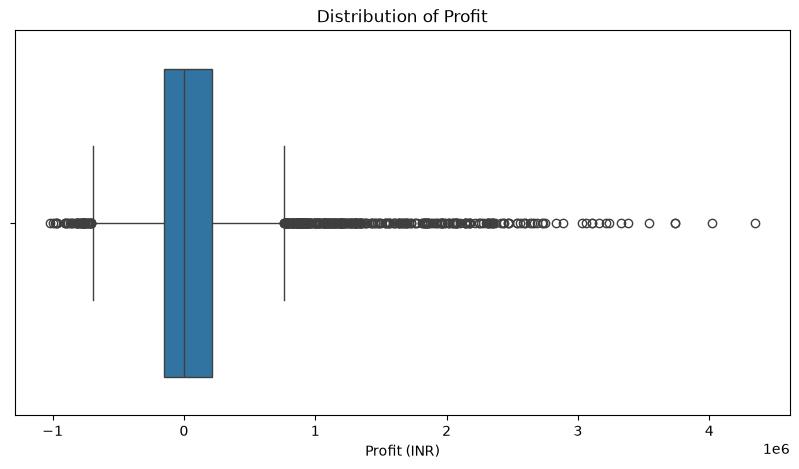

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Profit_INR'])

plt.title('Distribution of Profit')
plt.xlabel('Profit (INR)')
plt.show()

Extreme observations were identified using boxplots and descriptive statistics. Since unusually high agricultural performance may represent genuine farm-level observations, these records were retained unless they were identified as invalid values.

In [21]:
df.sample(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
217,SF10218,Gujarat,Warangal,Maize,Rabi,10.74,354.1,30.7,53.1,8.4,...,0.72,2.90,31.15,22268,854715,693648,-161067,3457,9.011,37.5
2876,SF12877,Gujarat,Nalgonda,Pulses,Rabi,2.31,280.9,20.3,42.0,7.3,...,0.99,0.32,0.74,77245,140936,57161,-83775,478,1.548,31.9
367,SF10368,Maharashtra,Warangal,Maize,Rabi,7.38,758.1,25.8,66.5,7.1,...,0.91,2.69,19.85,24734,538921,490970,-47951,2365,8.393,54.6
1458,SF11459,Punjab,Erode,Groundnut,Kharif,13.29,776.4,32.9,73.8,7.0,...,0.94,1.86,24.72,62510,848746,1545247,696501,3745,6.601,55.6
1932,SF11933,Tamil Nadu,Krishna,Cotton,Rabi,11.94,411.4,24.3,43.1,8.1,...,0.67,1.81,21.61,60279,922911,1302629,379718,12024,1.797,37.0
3881,SF13882,Telangana,Ludhiana,Cotton,Zaid,7.61,197.1,30.2,55.9,10.0,...,0.71,1.30,9.89,65049,523845,643335,119490,4406,2.245,35.4
2310,SF12311,Telangana,Erode,Wheat,Kharif,7.93,1016.7,25.2,68.8,6.3,...,0.79,1.74,13.80,21935,556803,302703,-254100,6682,2.065,59.6
2582,SF12583,Andhra Pradesh,Raichur,Wheat,Rabi,3.57,316.1,24.3,55.5,8.4,...,0.91,0.84,3.00,23670,232564,71010,-161554,2289,1.311,47.5
1776,SF11777,Gujarat,Ludhiana,Wheat,Kharif,12.51,710.1,27.5,67.1,6.1,...,0.98,2.41,30.15,23918,784297,721128,-63169,8163,3.693,47.7
3256,SF13257,Punjab,Guntur,Cotton,Kharif,7.34,813.3,28.7,76.5,8.1,...,0.73,1.70,12.48,64774,461887,808380,346493,2692,4.636,64.4


In [22]:
df['Profit_Margin_pct']=(df['Profit_INR']/df['Revenue_INR'])*100

In [23]:
df['Cost_per_Hectare']=(df['Total_Cost_INR']/df['Farm_Area_Hectares'])

In [24]:
df['Revenue_per_Hectare']=(df['Revenue_INR']/df['Farm_Area_Hectares'])

In [25]:
df['Profit_per_Hectare']=(df['Profit_INR']/df['Farm_Area_Hectares'])

In [26]:
outlier_summary=[]
for col in numeric_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    count=((df[col]<lower) | (df[col]>upper)).sum()
    outlier_summary.append({
    "Column":col,
    "Lower_Bound":lower,
    "Upper_Bound":upper,
    "Outlier_Count":count,
    "Outlier_Percentage":round(count/len(df)*100,2)
    })
outlier_summary=pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count",ascending=False
)
outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.000000,7.635670e+05,404,10.10
14,Production_Tonnes,-23.982500,5.335750e+01,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.572875,1.038412e+01,322,8.05
13,Yield_Tonnes_Ha,-1.620000,5.500000e+00,302,7.55
19,Water_Used_m3,-6072.750000,1.617125e+04,276,6.90
17,Revenue_INR,-736519.000000,1.780911e+06,240,6.00
9,Potassium_kg_ha,30.100000,1.797000e+02,32,0.80
4,Sunlight_Hours_Day,4.350000,1.035000e+01,26,0.65
8,Phosphorus_kg_ha,11.400000,1.042000e+02,16,0.40
10,Fertilizer_kg_ha,19.137500,3.520375e+02,15,0.38


#### Exploratory Data Analysis

##### Univariate Analysis

Season Distribution

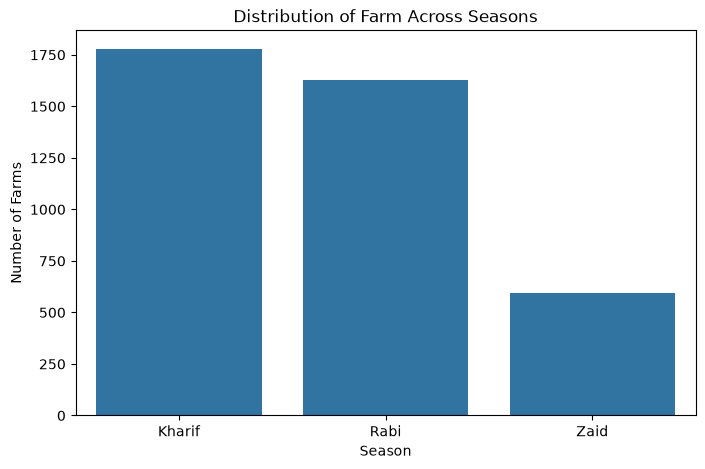

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Season')
plt.title("Distribution of Farm Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.show()

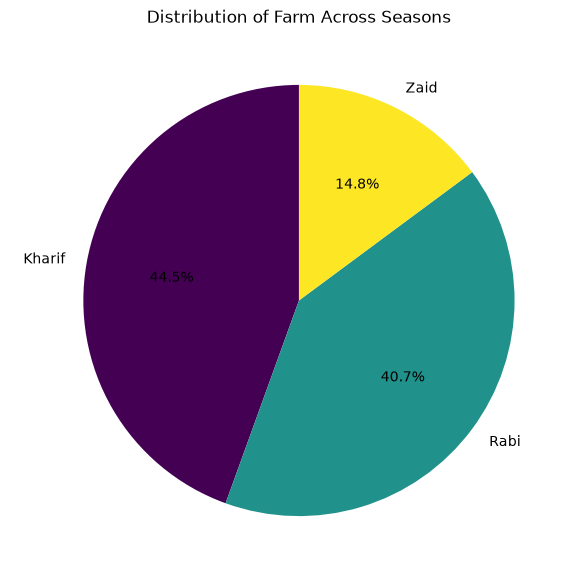

In [28]:
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,cmap='viridis')
plt.title("Distribution of Farm Across Seasons")
plt.ylabel(" ")
plt.show()

Crop Distribution

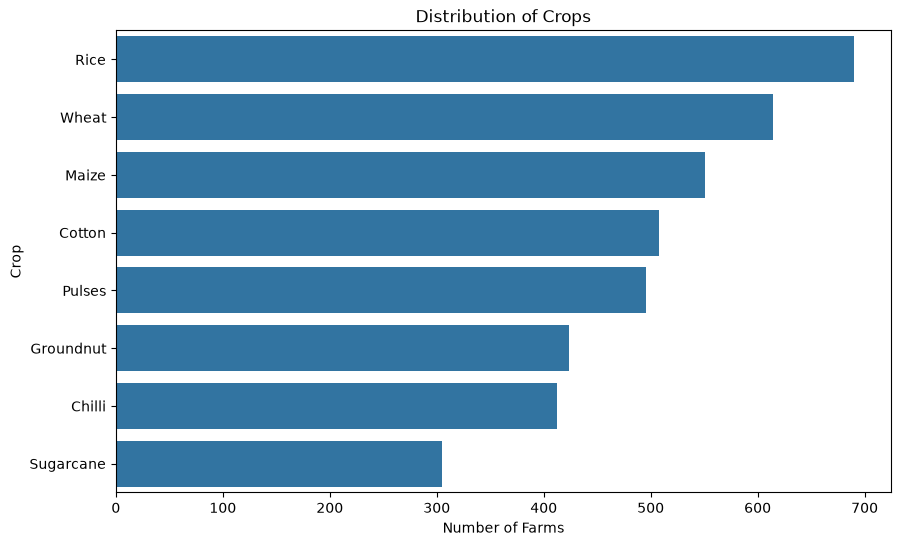

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,y='Crop',order=df['Crop'].value_counts().index)
plt.title("Distribution of Crops")
plt.ylabel("Crop")
plt.xlabel("Number of Farms")
plt.show()

State-wise Distribution

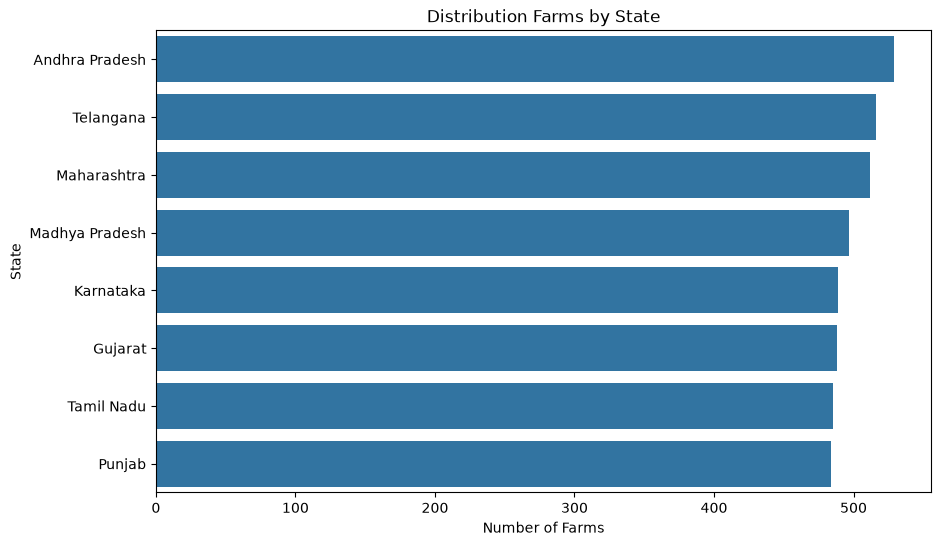

In [30]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,y='State',order=df['State'].value_counts().index)
plt.title("Distribution Farms by State")
plt.ylabel("State")
plt.xlabel("Number of Farms")
plt.show()

Yield Distribution

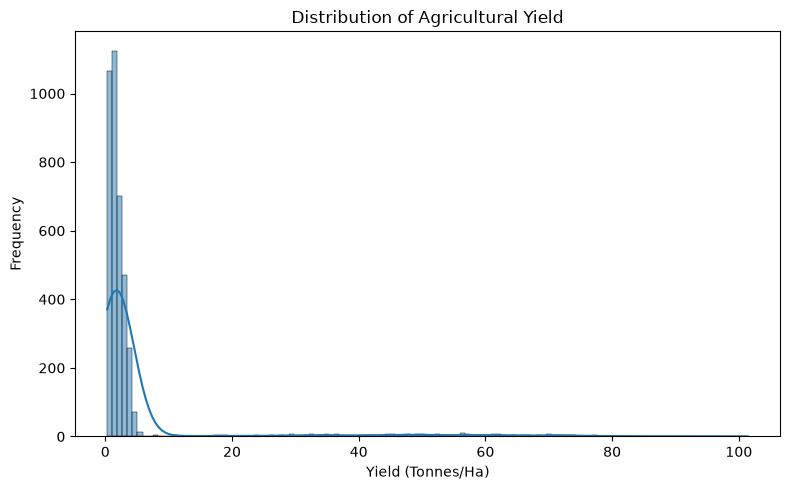

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Yield_Tonnes_Ha",kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##### Bivariate Analysis

Season vs Crop

In [32]:
season_crop=pd.crosstab(df['Season'],df['Crop'])
season_crop

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


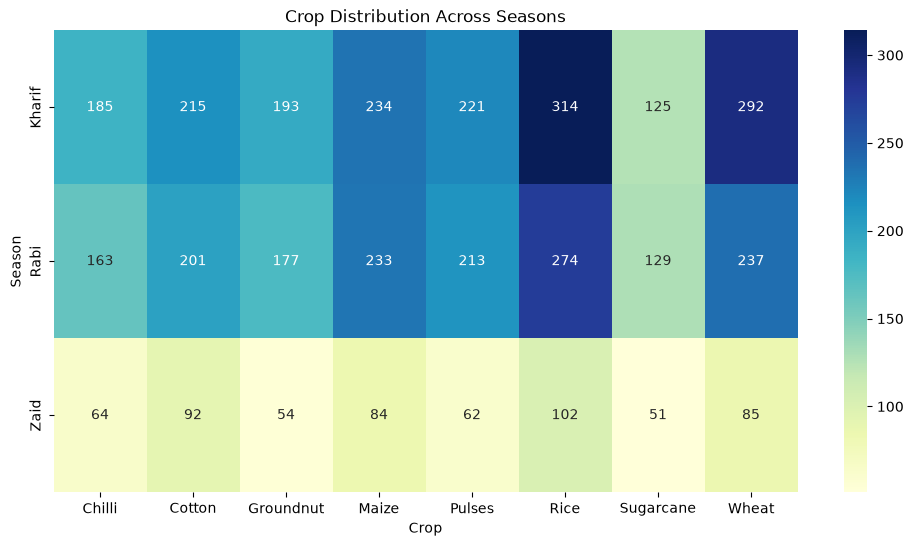

In [33]:
plt.figure(figsize=(12,6))
sns.heatmap(season_crop,annot=True,fmt='d',cmap='YlGnBu')
plt.title("Crop Distribution Across Seasons")
plt.xlabel('Crop')
plt.ylabel('Season')
plt.show()

Crop vs Yield

In [34]:
crop_yield=(
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)
crop_yield

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64

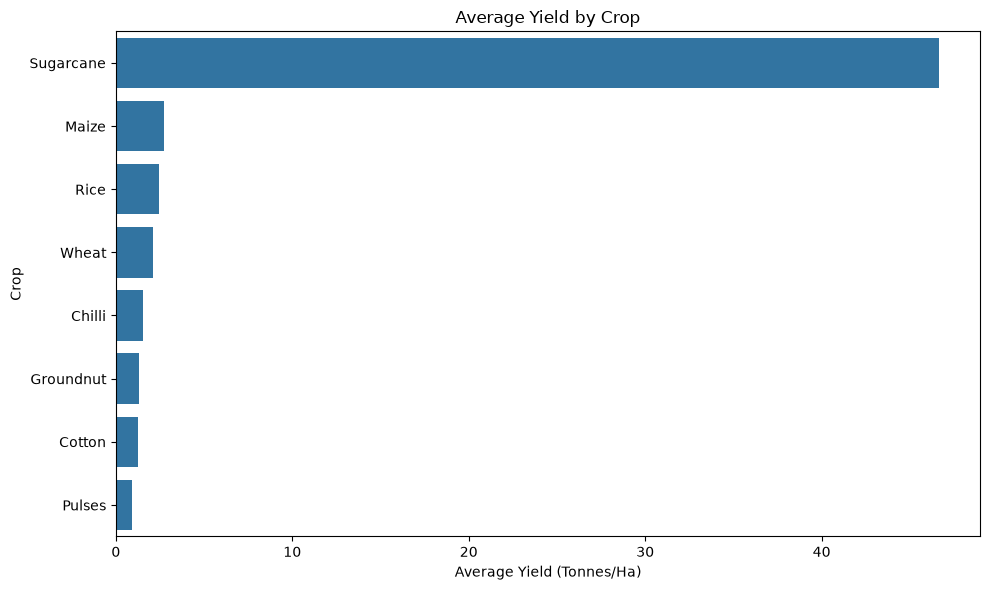

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index)
plt.title("Average Yield by Crop")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

Rainfall vs Yield

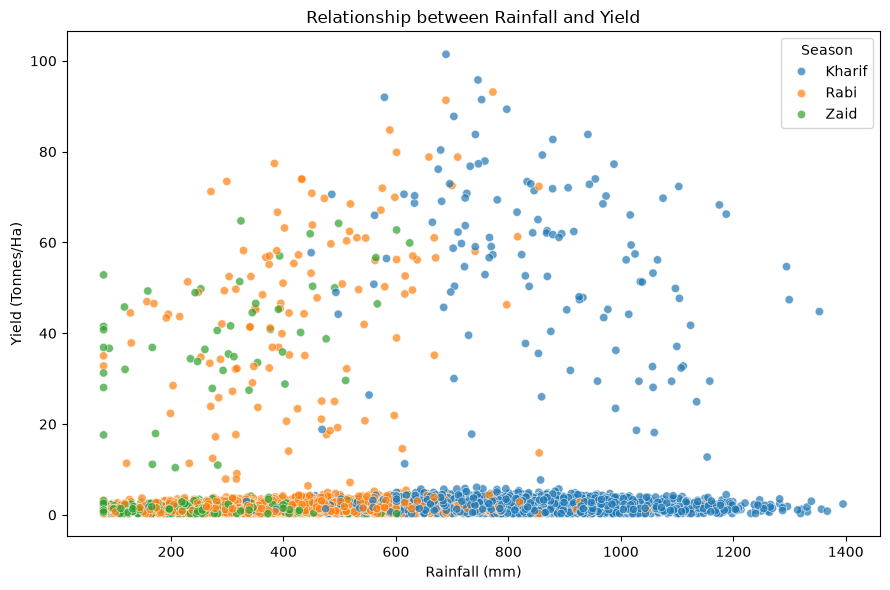

In [36]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.7
)
plt.title("Relationship between Rainfall and Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

Disease/Pest Risk vs Yield

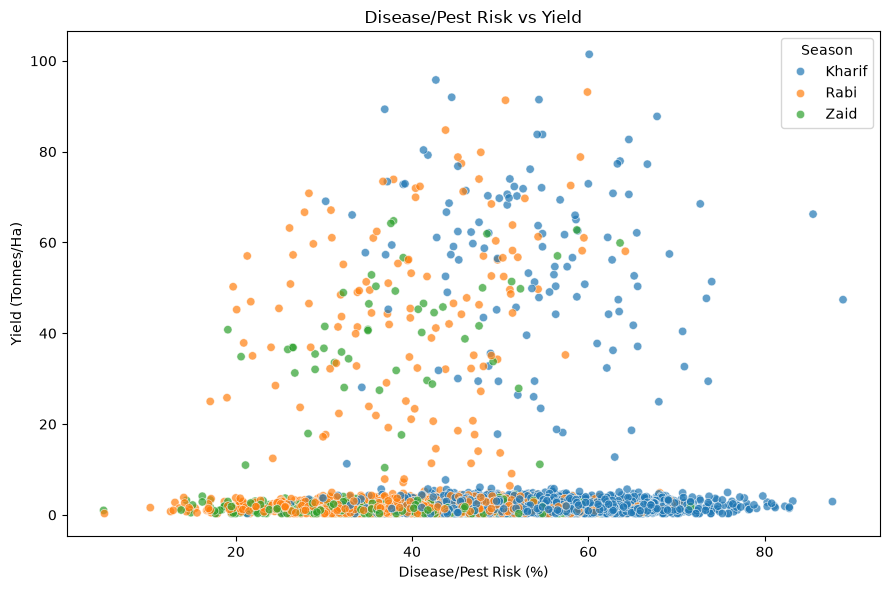

In [37]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.7
)
plt.title('Disease/Pest Risk vs Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

##### Multivariate Analysis

Crop + Season vs Yield

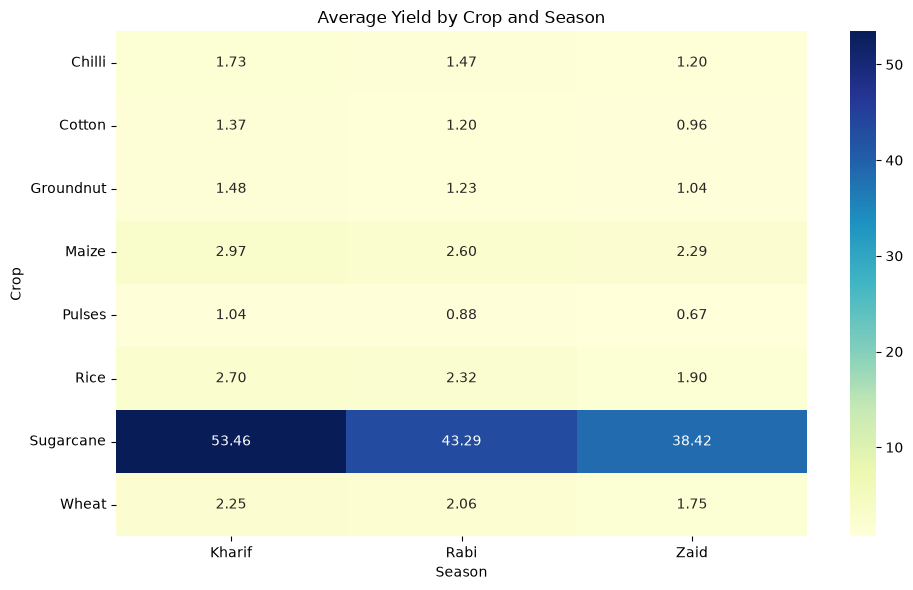

In [38]:
pivot_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)
plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

##### Irrigation + Season vs Yield

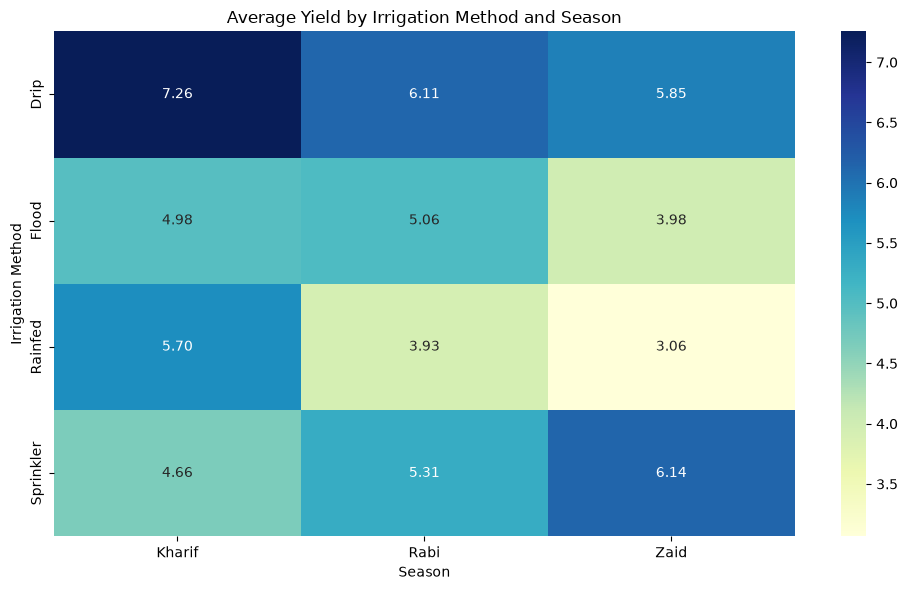

In [39]:
irrigation_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Irrigation_Method',
    columns='Season',
    aggfunc='mean'
)
plt.figure(figsize=(10,6))
sns.heatmap(
    irrigation_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)
plt.title('Average Yield by Irrigation Method and Season')
plt.xlabel('Season')
plt.ylabel('Irrigation Method')
plt.tight_layout()
plt.show()

### Seasonal Agricultural Performance

In [40]:
season_summary=df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)
season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Total_Cost_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,178914.65,531804.41,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,87689.47,513836.58,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,-24804.82,543976.73,6419.89,4.41,38.22


Which Season has the highest agricultural yield?

In [41]:
season_yield=df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
season_yield

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64

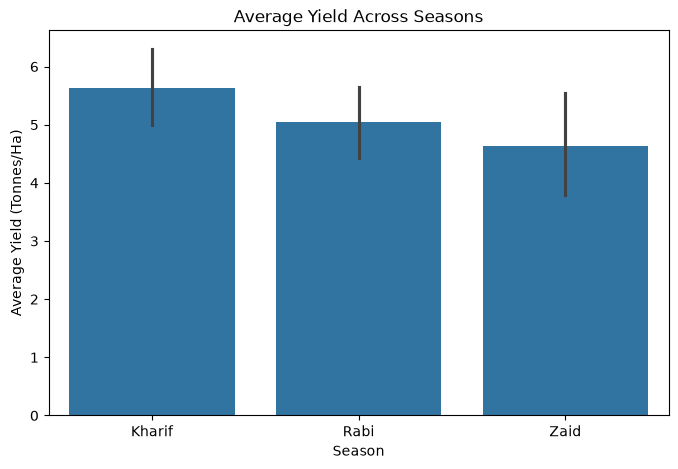

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)
plt.title('Average Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

Which season generates the highest profit?

In [43]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)
season_profit

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

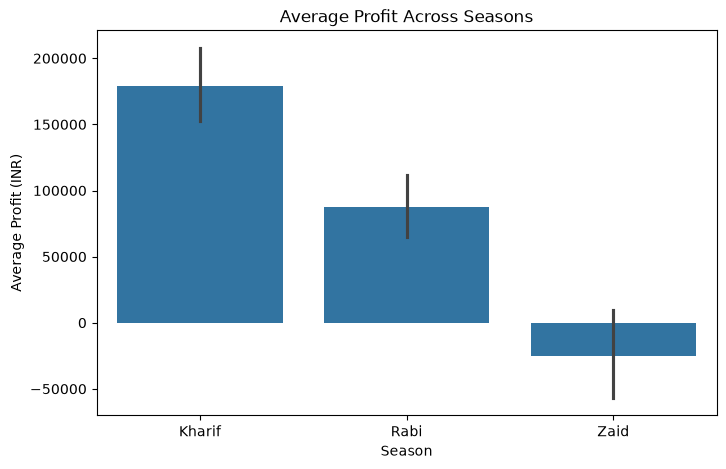

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)
plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

Which season has the highest revenue?

In [45]:
df.groupby('Season')['Revenue_INR'].mean().sort_values(ascending=False)

Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64

Does season affect production?

In [46]:
season_production = df.groupby('Season')['Production_Tonnes'].mean()
season_production

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64

Does temperature affect yield? 

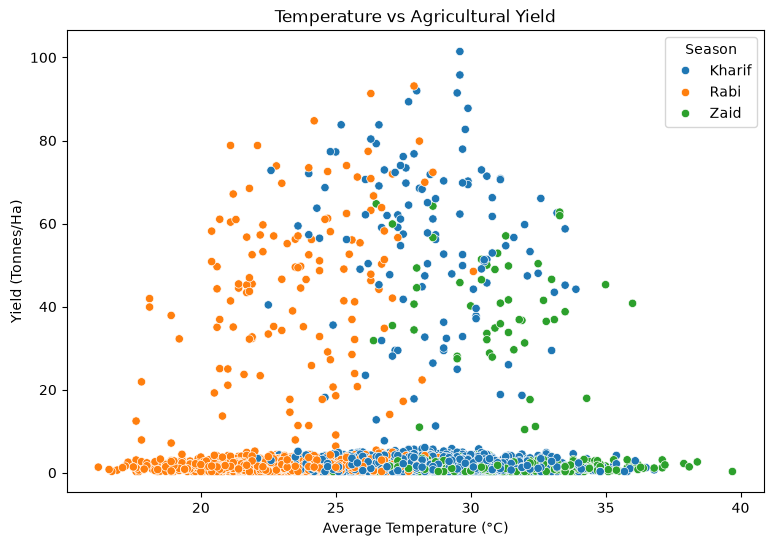

In [47]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)
plt.title('Temperature vs Agricultural Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

Which Irrigation method performs best?

In [48]:
irrigation_summary = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)
irrigation_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,,
Drip,6.58,57.99,219626.00,5918.75,6.27
Flood,4.86,38.73,73354.02,8026.47,3.44
Rainfed,4.60,36.61,79050.37,3549.55,7.56
Sprinkler,5.16,42.34,91121.08,6208.26,4.67


Which Irrigation method is most water efficient?

In [49]:
df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(
    ascending=False
)

Irrigation_Method
Rainfed      7.563784
Drip         6.267129
Sprinkler    4.669805
Flood        3.438853
Name: Water_Efficiency_t_per_1000m3, dtype: float64

Which crops are most profitable?

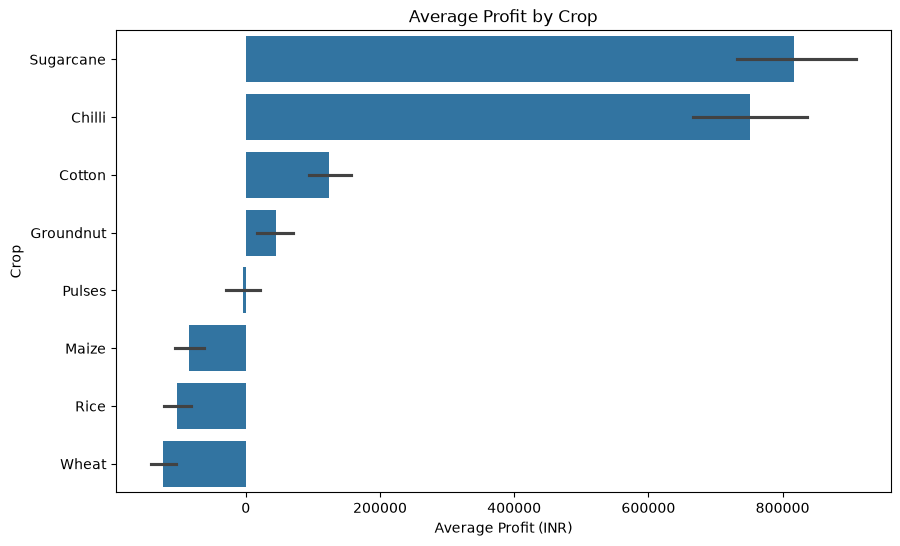

In [50]:
crop_profit = df.groupby('Crop').agg({
    'Profit_INR': 'mean',
    'Revenue_INR': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    y='Crop',
    x='Profit_INR',
    estimator='mean',
    order=crop_profit.index
)
plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.show()

Does Fertilizer usage affect yield?

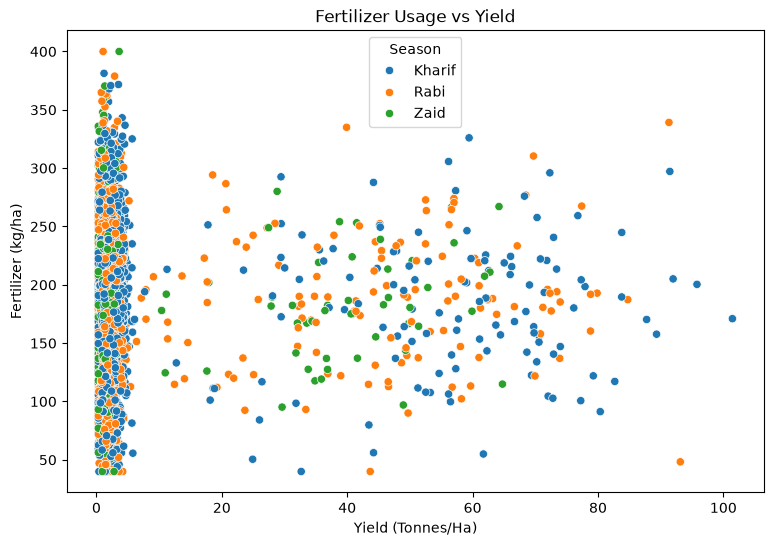

In [53]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    y='Fertilizer_kg_ha',
    x='Yield_Tonnes_Ha',
    hue='Season'
)
plt.title('Fertilizer Usage vs Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Fertilizer (kg/ha)')
plt.show()

Which season has the highest disease/pest risk?

In [54]:
risk_summary = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(
    ascending=False)
risk_summary

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

Which states perform best?

In [55]:
state_summary = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

state_summary.sort_values(
    'Profit_INR',
    ascending=False
)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3
State,,,,,
Punjab,6.12,52.23,686225.70,136025.64,5.62
Maharashtra,5.02,43.98,650032.67,135428.86,5.28
Karnataka,5.69,47.73,653426.18,119422.34,5.56
Tamil Nadu,4.88,40.84,629093.42,117744.75,5.31
Gujarat,5.66,48.33,654692.86,117568.24,5.58
Telangana,5.04,39.25,628784.53,108829.62,5.46
Madhya Pradesh,4.99,37.56,597558.36,86840.76,5.27
Andhra Pradesh,4.63,36.91,606663.66,73453.53,5.03


Which crop+season combination performs best?

In [56]:
crop_season = df.groupby(
    ['Crop', 'Season']).agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Revenue_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)
crop_season.sort_values(
    'Profit_INR',
    ascending=False
).head(10)

,,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Water_Efficiency_t_per_1000m3
Crop,Season,,,,
Sugarcane,Kharif,53.46,1000790.81,1561828.16,36.00
Chilli,Kharif,1.73,954380.42,1494091.73,3.26
Sugarcane,Rabi,43.29,731612.86,1269754.74,27.92
Chilli,Rabi,1.47,638572.50,1140992.37,2.89
Sugarcane,Zaid,38.42,583635.80,1165236.35,23.39
Chilli,Zaid,1.20,448659.09,994429.55,2.20
Cotton,Kharif,1.37,216999.55,713739.94,2.13
Groundnut,Kharif,1.48,108265.44,594414.86,3.58
Cotton,Rabi,1.20,107343.59,637722.18,1.94


#### Conclusion

The analysis provided useful insights into how agricultural performance varies across seasons, crops, environmental conditions and farming practices. The findings highlight differences in yield, resource usage and economic performance, which can support better seasonal planning and decision-making.